# YOLO-style training pipeline with `instance_binding`

This notebook builds an Ultralytics-flavored training augmentation stack on top of AlbumentationsX 2.2.2 — the kind of pipeline you'd use to train YOLO11-seg on a custom instance-segmentation dataset, but assembled out of pure Albumentations primitives so you can swap pieces in and out.

Pipeline:

| Ultralytics op | Albumentations equivalent |
| --- | --- |
| `Mosaic` | [`A.Mosaic`](https://explore.albumentations.ai/transform/Mosaic) |
| `CopyPaste` | [`A.CopyAndPaste`](https://explore.albumentations.ai/transform/CopyAndPaste) (new in 2.2.0) |
| `RandomPerspective` | [`A.Perspective`](https://explore.albumentations.ai/transform/Perspective) + [`A.Affine`](https://explore.albumentations.ai/transform/Affine) |
| `Fliplr` | [`A.HorizontalFlip`](https://explore.albumentations.ai/transform/HorizontalFlip) |
| `HSV` jitter | [`A.HueSaturationValue`](https://explore.albumentations.ai/transform/HueSaturationValue) |
| brightness / contrast | [`A.RandomBrightnessContrast`](https://explore.albumentations.ai/transform/RandomBrightnessContrast) |

Everything runs under `Compose(instance_binding=["masks", "bboxes"])`, so the per-instance dict format you feed in is exactly what comes back out — including pasted instances and instances that survive Mosaic cropping.

For an introduction to `instance_binding` itself, see [`example_instance_binding.ipynb`](example_instance_binding.ipynb).

## Heads-up: 2.2.0+ API conventions

- All sampling-range constructor args end in `_range` (`Rotate.angle_range`, `HueSaturationValue.hue_shift_range`, `Blur.blur_range`, …). The old `*_limit` names are removed.
- Range args are tuples only — pass `(-15, 15)`, not `15`.
- Per-instance `bbox_labels` and `keypoint_labels` are dicts keyed by `BboxParams.label_fields` / `KeypointParams.label_fields`. Bare lists raise `TypeError`.

## Version notes

- **2.2.2** — fixes the last `instance_binding` ordering bug (`Mosaic → Perspective → CopyAndPaste` no longer crashes the mask resync). All transform orderings used in this notebook work.
- **2.2.1** — fixed `Affine` / `ShiftScaleRotate` after `Mosaic`, and `Mosaic + CopyAndPaste + Perspective`.
- **2.2.0** — initial release of `instance_binding` and `CopyAndPaste`.

Pin `albumentationsx>=2.2.2` if you want this exact pipeline.

In [ ]:
!pip install -q 'albumentationsx>=2.2.2' matplotlib


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from __future__ import annotations

import io
import urllib.request
import zipfile
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

print("albumentations", A.__version__)

albumentations 2.2.2


## Load `coco128-seg`

Same dataset and loader as [`example_instance_binding.ipynb`](example_instance_binding.ipynb): 128 COCO val images with YOLO-format polygon annotations, ~7 MB. We rasterize each polygon into a binary instance mask.

In [ ]:
DATA_ROOT = Path("../data/coco128-seg")
DATASET_URL = "https://www.ultralytics.com/assets/coco128-seg.zip"

COCO_NAMES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard",
    "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard",
    "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase",
    "scissors", "teddy bear", "hair drier", "toothbrush",
]


def ensure_dataset() -> Path:
    if DATA_ROOT.exists() and any(DATA_ROOT.glob("images/train2017/*.jpg")):
        return DATA_ROOT
    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(DATASET_URL) as resp:
        buf = io.BytesIO(resp.read())
    with zipfile.ZipFile(buf) as zf:
        zf.extractall(DATA_ROOT.parent)
    return DATA_ROOT


def load_sample(image_path: Path) -> tuple[np.ndarray, list[dict]]:
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    label_path = DATA_ROOT / "labels" / "train2017" / (image_path.stem + ".txt")
    instances: list[dict] = []
    if not label_path.exists():
        return image, instances
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 7:
            continue
        class_idx = int(parts[0])
        coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
        coords[:, 0] *= w
        coords[:, 1] *= h
        polygon = coords.round().astype(np.int32)
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(mask, [polygon], 1)
        if mask.sum() == 0:
            continue
        ys, xs = np.where(mask > 0)
        bbox = np.array([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1], dtype=np.float32)
        instances.append({
            "mask": mask,
            "bbox": bbox,
            "bbox_labels": {"class_name": COCO_NAMES[class_idx]},
        })
    return image, instances


ensure_dataset()
image_paths = sorted(DATA_ROOT.glob("images/train2017/*.jpg"))
print(f"{len(image_paths)} images")

128 images


## Build a 16-image pool

We pre-load 16 samples once. Each call to the augmentation pipeline samples a primary, three Mosaic neighbors, and a few standalone donor instances for `CopyAndPaste`.

In [ ]:
POOL_SIZE = 16
pool: list[tuple[np.ndarray, list[dict]]] = []
for p in image_paths:
    image, instances = load_sample(p)
    if len(instances) >= 1:
        pool.append((image, instances))
    if len(pool) >= POOL_SIZE:
        break
print(f"pool: {len(pool)} samples, {sum(len(i) for _, i in pool)} total instances")

pool: 16 samples, 72 total instances


## Pipeline + per-call data assembly

`Mosaic` and `CopyAndPaste` consume their own metadata keys (`mosaic_metadata`, `copy_paste_metadata`). The shape of those metadata entries is **independent** of `instance_binding`: Mosaic wants per-image dicts (`masks` `(N, H, W)`, `bboxes` `(N, 4)`, `bbox_labels` `{field: [list]}`), CopyAndPaste wants per-object dicts (`mask`, `bbox_labels` `{field: value}`).

Ultralytics' `RandomPerspective` is one fused affine + perspective warp; here we split it into [`A.Affine`](https://explore.albumentations.ai/transform/Affine) (rotate / shear / scale / translate) and [`A.Perspective`](https://explore.albumentations.ai/transform/Perspective) (small projective warp), both placed after `Mosaic`. As of 2.2.2 every ordering in this pipeline is safe under `instance_binding`.

In [ ]:
transform = A.Compose(
    [
        A.Mosaic(
            grid_yx=(2, 2),
            target_size=(640, 640),
            cell_shape=(640, 640),
            fit_mode="cover",
            p=1.0,
        ),
        A.Affine(
            scale=(0.9, 1.1),
            rotate=(-10, 10),
            shear=(-2, 2),
            translate_percent=(-0.05, 0.05),
            p=0.5,
        ),
        A.Perspective(
            scale=(0.02, 0.05),
            keep_size=True,
            fit_output=False,
            p=0.3,
        ),
        A.CopyAndPaste(
            scale_range=(0.4, 1.0),
            blend_mode="gaussian",
            blend_sigma_range=(1.0, 2.0),
            min_visibility_after_paste=0.1,
            p=0.7,
        ),
        A.HorizontalFlip(p=0.5),
        A.HueSaturationValue(
            hue_shift_range=(-15, 15),
            sat_shift_range=(-40, 40),
            val_shift_range=(-25, 25),
            p=1.0,
        ),
        A.RandomBrightnessContrast(
            brightness_range=(-0.2, 0.2),
            contrast_range=(-0.2, 0.2),
            p=0.5,
        ),
    ],
    bbox_params=A.BboxParams(
        coord_format="pascal_voc",
        label_fields=["class_name"],
        min_visibility=0.1,
        min_area=8.0,
    ),
    instance_binding=["masks", "bboxes"],
    seed=42,
)

In [ ]:
def make_call_data(rng: np.random.Generator, n_mosaic: int = 3, n_paste: int = 4) -> dict:
    """Sample a primary + Mosaic neighbors + CopyAndPaste donors from the pool."""
    indices = rng.choice(len(pool), size=1 + n_mosaic, replace=False)
    primary_image, primary_instances = pool[int(indices[0])]

    mosaic_metadata = []
    for idx in indices[1:]:
        img, instances = pool[int(idx)]
        if not instances:
            continue
        mosaic_metadata.append({
            "image": img,
            "masks": np.stack([i["mask"] for i in instances]),
            "bboxes": np.stack([i["bbox"] for i in instances]),
            "bbox_labels": {"class_name": [i["bbox_labels"]["class_name"] for i in instances]},
        })

    flat = [(img, inst) for img, instances in pool for inst in instances]
    paste_indices = rng.choice(len(flat), size=min(n_paste, len(flat)), replace=False)
    copy_paste_metadata = [
        {
            "image": flat[int(k)][0],
            "mask": flat[int(k)][1]["mask"],
            "bbox_labels": {"class_name": flat[int(k)][1]["bbox_labels"]["class_name"]},
        }
        for k in paste_indices
    ]

    return {
        "image": primary_image,
        "instances": primary_instances,
        "mosaic_metadata": mosaic_metadata,
        "copy_paste_metadata": copy_paste_metadata,
    }

## Visualize 6 augmented samples

Each call assembles a fresh primary + Mosaic neighbors + paste donors and runs the full pipeline. `out["instances"]` is the per-object list — same shape you fed in, with surviving primaries + freshly pasted instances.

In [ ]:
_RNG = np.random.default_rng(0)
_COLOR_CACHE: dict[int, tuple[float, float, float]] = {}


def _color_for(idx: int) -> tuple[float, float, float]:
    if idx not in _COLOR_CACHE:
        _COLOR_CACHE[idx] = tuple(_RNG.uniform(0.3, 1.0, size=3))
    return _COLOR_CACHE[idx]


def draw_instances(ax: plt.Axes, image: np.ndarray, instances: list[dict], title: str = "") -> None:
    overlay = image.astype(np.float32).copy()
    for i, inst in enumerate(instances):
        color = np.array(_color_for(i)) * 255
        mask = inst.get("mask")
        if mask is not None:
            blend = (mask > 0)[..., None]
            overlay = np.where(blend, 0.5 * overlay + 0.5 * color, overlay)
    ax.imshow(np.clip(overlay, 0, 255).astype(np.uint8))
    for i, inst in enumerate(instances):
        x1, y1, x2, y2 = inst["bbox"]
        color = _color_for(i)
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=1.5))
        label = inst.get("bbox_labels", {}).get("class_name", "?")
        ax.text(x1, max(0, y1 - 4), label, color="white", fontsize=8,
                bbox=dict(facecolor=color, alpha=0.8, edgecolor="none", pad=1))
    ax.set_title(title)
    ax.axis("off")

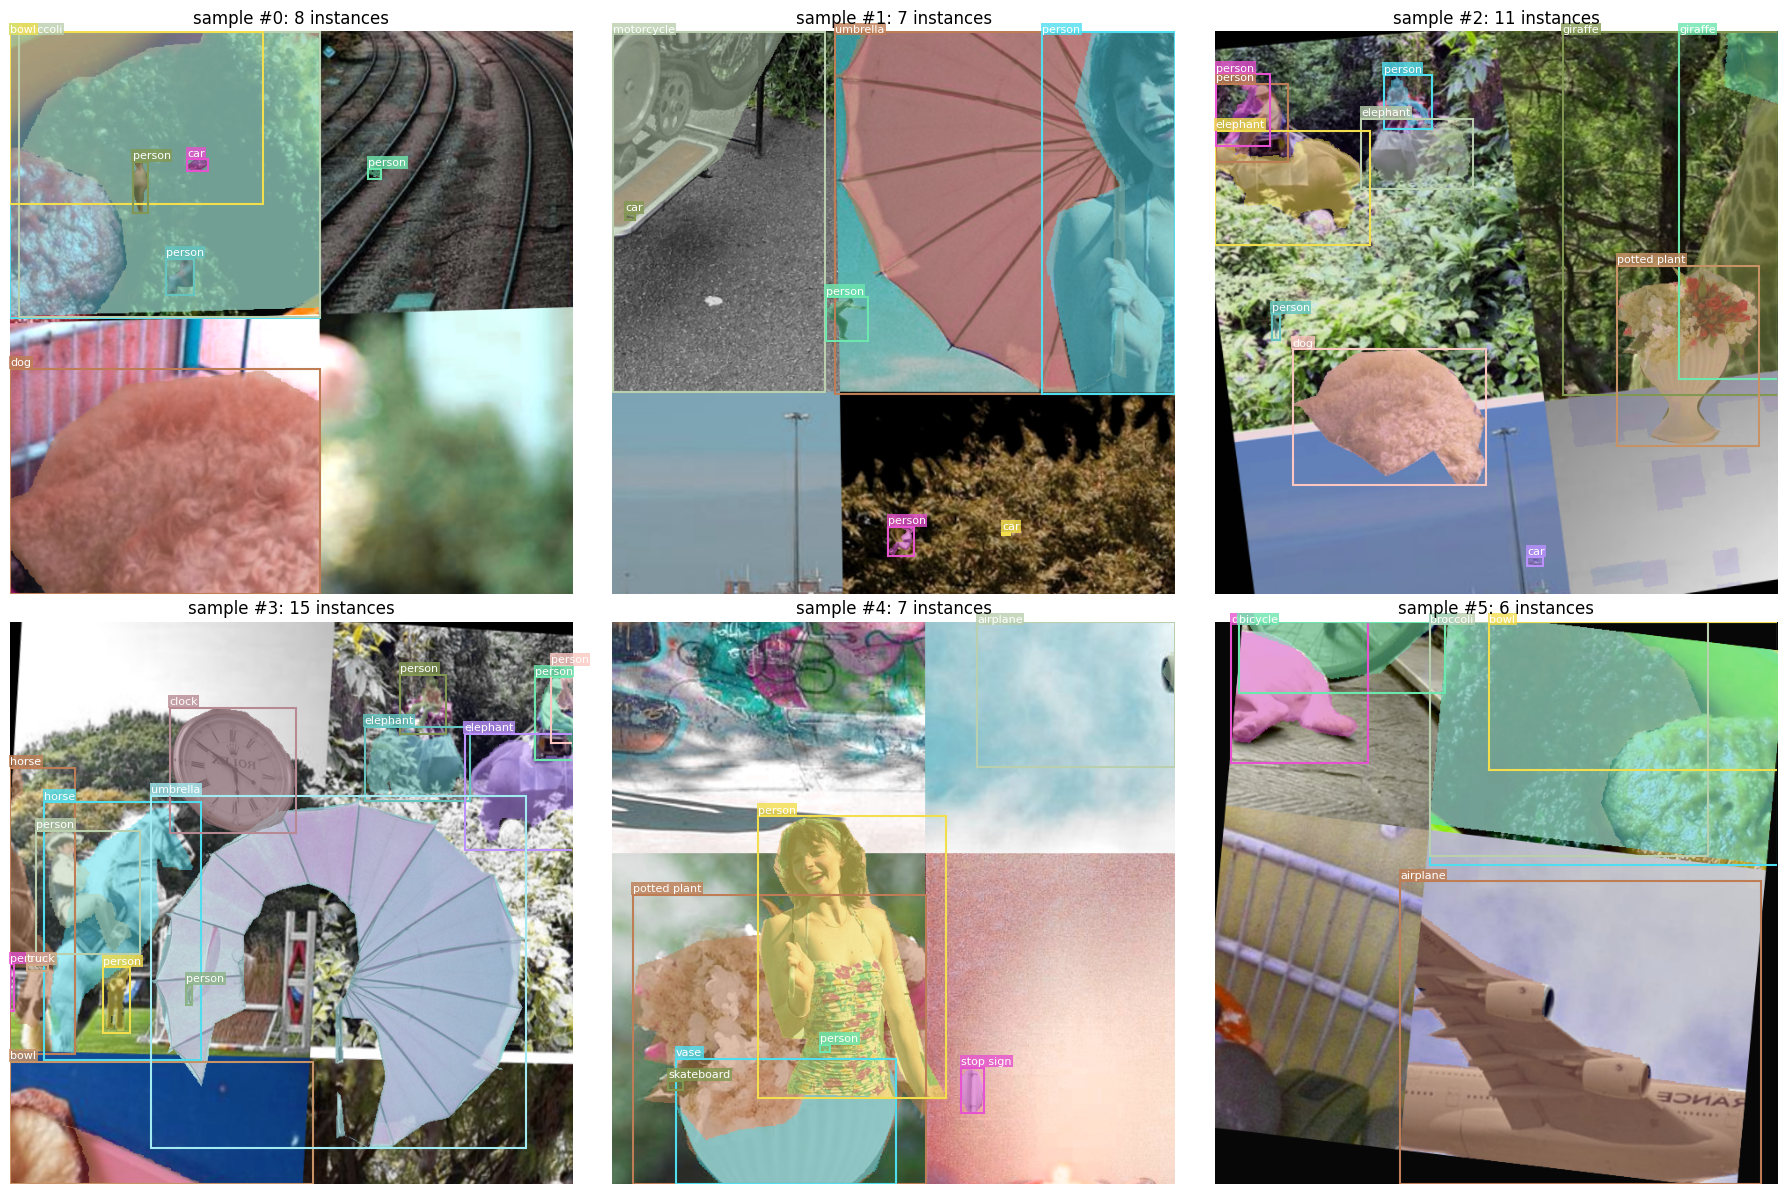

In [ ]:
rng = np.random.default_rng(2026)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
for i, ax in enumerate(axes):
    transform.set_random_seed(int(rng.integers(0, 1_000_000)))
    data = make_call_data(rng)
    out = transform(**data)
    draw_instances(
        ax,
        out["image"],
        out["instances"],
        title=f"sample #{i}: {len(out['instances'])} instances",
    )
plt.tight_layout()
plt.show()

## Sanity check: instance dicts round-trip

Confirm the output `instances` is the same list-of-dicts shape you'd hand to a Mask-RCNN-style head — every entry has `mask` (`(H, W)` binary), `bbox` (`(4,)` pascal_voc), and `bbox_labels` (`{"class_name": str}`).

In [ ]:
rng = np.random.default_rng(0)
transform.set_random_seed(0)
data = make_call_data(rng)
out = transform(**data)

print(f"image: {out['image'].shape}  dtype={out['image'].dtype}")
print(f"instances: {len(out['instances'])}")
for i, inst in enumerate(out["instances"]):
    print(
        f"  [{i}] keys={sorted(inst.keys())}  "
        f"mask={inst['mask'].shape}  bbox={inst['bbox'].round(1).tolist()}  "
        f"label={inst['bbox_labels']}",
    )

image: (640, 640, 3)  dtype=uint8
instances: 10
  [0] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[0.0, 0.0, 374.8, 353.9]  label={'class_name': 'umbrella'}
  [1] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[0.0, 0.0, 133.7, 353.9]  label={'class_name': 'person'}
  [2] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[397.9, 0.0, 521.9, 52.3]  label={'class_name': 'elephant'}
  [3] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[522.5, 0.0, 632.0, 87.4]  label={'class_name': 'elephant'}
  [4] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[0.0, 353.8, 383.1, 640.0]  label={'class_name': 'motorcycle'}
  [5] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[44.0, 328.4, 396.5, 640.0]  label={'class_name': 'motorcycle'}
  [6] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[29.0, 361.0, 332.0, 579.0]  label={'class_name': 'bowl'}
  [7] keys=['bbox', 'bbox_labels', 'mask']  mask=(640, 640)  bbox=[31

## Wiring this into a training loop

```python
class CocoSegDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, transform, pool):
        self.image_paths = image_paths
        self.transform = transform
        self.pool = pool
        self.rng = np.random.default_rng()

    def __getitem__(self, idx):
        image, instances = load_sample(self.image_paths[idx])
        # sample 3 Mosaic neighbors + a few donors from the same training pool
        mosaic_metadata, copy_paste_metadata = sample_metadata(self.pool, self.rng)
        out = self.transform(
            image=image,
            instances=instances,
            mosaic_metadata=mosaic_metadata,
            copy_paste_metadata=copy_paste_metadata,
        )
        return out["image"], out["instances"]
```

From there, model-specific collate (Mask-RCNN expects `targets[i] = {boxes, masks, labels}`; YOLO-seg expects per-image polygon tensors) is a one-liner over `out["instances"]`.

## What this notebook deliberately doesn't replicate

- **`MixUp`** — not yet a first-class transform. Roll your own with `image = alpha * image_a + (1 - alpha) * image_b` and concatenate the instance lists.
- **Auto-anchor / letterbox-resize** — model-side concerns, not augmentation.

If you need the actual Ultralytics training loop with custom Albumentations injected, see [`example_ultralytics.ipynb`](example_ultralytics.ipynb).